# **Decoding ancient economy: Using anomaly detection**

Using Apache Spark, PySpark MLlib, and clustering-based anomaly detection, our project investigates whether the physical features of economic clay tablets reveals hidden economic structures, administrative standardization, or rare archival anomalies in Old Babylonian Mesopotamia.

---

## **Metadata**

## Dataset Source

The dataset used in this project originates from the CDLI (Cuneiform Digital Library Initiative), a major digital archive of cuneiform inscriptions from ancient Mesopotamia. We extracted the data from the repository of cdli bulk data dump in github with data updated till 2022.

CDLI aggregates archaeological metadata from museums, excavation archives, and research collections worldwide, providing structured records for thousands of ancient clay tablets.

The original dataset contains:
- archaeological provenience
- tablet classifications
- physical measurements
- chronological information
- and catalog metadata

This project specifically focuses on economic tablets and their physical dimensions for machine learning analysis.



In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
from pyspark.sql import SparkSession
spark= SparkSession.builder \
    .appName("Babylonian_Economy_Tracker") \
    .master("local[*]") \
    .config("spark.driver.memory", "4g") \
    .getOrCreate()

Ancient Mesopotamian economies generated thousands of clay tablets recording trade, taxation, labor, legal contracts, and administrative transactions.

However, archaeological datasets are extremely *noisy, inconsistent in measurement formats, incomplete*, and difficult to analyze manually.

---

## Problem Statement

This project asks:

#### **Can machine learning identify hidden structural patterns or unusual economic artifacts purely from the physical dimensions of tablets?**

---
Instead of reading tablet text content, we study the physical features of economic tablets themselves:
1. Height
2. Width
3. Thickness

## Assumptions
We assume that administrative systems may have standardized tablet production, while unusual tablets may indicate:
- elite transactions
- archival irregularities
- specialized trade
- unique bureaucratic practices

In [ ]:
file_path = '/content/drive/MyDrive/Ancient_Data /cdli_cat.txt'
df = spark.read.csv(file_path, header=True, inferSchema=True)
print("Original CDLI Dataset Overview")
print(f"Total Rows: {df.count()}")
print(f"Total Columns: {len(df.columns)}")
print("\nAvailable Columns:")
print(df.columns)



Original CDLI Dataset Overview
Total Rows: 353283
Total Columns: 64

Available Columns:
['accession_no', 'accounting_period', 'acquisition_history', 'alternative_years', 'ark_number', 'atf_source', 'atf_up', 'author', 'author_remarks', 'cdli_collation', 'cdli_comments', 'citation', 'collection', 'composite_id', 'condition_description', 'date_entered', 'date_of_origin', 'date_remarks', 'date_updated', 'dates_referenced', 'db_source', 'designation', 'dumb', 'dumb2', 'electronic_publication', 'elevation', 'excavation_no', 'external_id', 'findspot_remarks', 'findspot_square', 'genre', 'google_earth_collection', 'google_earth_provenience', 'height', 'id', 'id_text2', 'id_text', 'join_information', 'language', 'lineart_up', 'material', 'museum_no', 'object_preservation', 'object_type', 'period', 'period_remarks', 'photo_up', 'primary_publication', 'provenience', 'provenience_remarks', 'publication_date', 'publication_history', 'published_collation', 'seal_id', 'seal_information', 'stratigrap

## Raw Archaeological Dataset

The original CDLI archive contains 3,53,283 records distributed across 64 variables covering multiple Mesopotamian periods, object types, excavation records, and publication details.

The dataset includes:
- historical classification
- archaeological provenience
- material descriptions
- preservation conditions
- textual metadata
- physical measurements

As the archive spans diverse object categories and historical periods, substantial filtering was required before machine learning analysis could begin.

---

## Data Filtration

To reduce chronological variation and maintain historical consistency, the dataset was filtered to retain only records associated with the Old Babylonian period.

This step reduced the dataset to tablets belonging to a more coherent administrative and economic environment suitable for comparative analysis.

In [ ]:
print("Filtering for Old Babylonian records...")
babylon_df = df.filter(df['period'].contains('Old Babylonian'))
record_count = babylon_df.count()
print(f"Extracted {record_count} Babylonian records.")
babylon_df.select("id_text", "provenience", "period", "material").show(5)

Filtering for Old Babylonian records...
Extracted 75467 Babylonian records.
+-------+--------------------+--------------------+--------+
|id_text|         provenience|              period|material|
+-------+--------------------+--------------------+--------+
|  10733|Kisurra (mod. Abu...|Old Babylonian (c...|    clay|
| 101741|Nippur (mod. Nuffar)|Old Babylonian (c...|    clay|
| 142806|Kish (mod. Tell U...|Old Babylonian (c...|    clay|
| 102549|Nippur (mod. Nuffar)|Old Babylonian (c...|    clay|
| 102551|Nippur (mod. Nuffar)|Old Babylonian (c...|    clay|
+-------+--------------------+--------------------+--------+
only showing top 5 rows


## Selecting Economic Tablets

The filtered Babylonian dataset still contained multiple tablet genres and object categories.

For this project, only economic and administrative tablets were used because they are more likely to reflect:
- trade activity
- taxation systems
- labor administration
- bureaucratic standardization practices

This produced the final analytical dataset used for machine learning modeling.

---

## Variables Used for Analysis

Although the original archive contains 64 archaeological data fields, only variables relevant to dimensional analysis and machine learning were retained.

The selected variables were chosen because they provide:
- physical tablet geometry
- archaeological identification
- measurable numerical structure suitable for clustering and anomaly detection

So we used:

| Variable | Description | Type | Used For |
|---|---|---|---|
| id_text | Unique tablet identification number | Qualitative (Identifier) | Tablet tracking |
| provenience | Archaeological origin/site of discovery | Qualitative (Categorical) | Geographic context |
| genre | Tablet classification category | Qualitative (Categorical) | Economic tablet filtering |
| height | Physical tablet height measurement | Quantitative (Continuous) | ML feature |
| width | Physical tablet width measurement | Quantitative (Continuous) | ML feature |
| thickness | Physical tablet thickness measurement | Quantitative (Continuous) | ML feature |
| features | Combined feature vector | Quantitative (Vector) | Feature engineering |
| scaled_features | Standardized numerical features | Quantitative (Vector) | ML modeling |
| cluster | K-Means cluster assignment | Quantitative (Discrete) | Unsupervised learning |
| distance | Distance from assigned centroid | Quantitative (Continuous) | Anomaly scoring |
| anomaly | Binary anomaly label | Quantitative (Binary) | Classification target |

The original archaeological dataset contains substantial inconsistencies, malformed measurements, unit irregularities, and missing values. Significant preprocessing and normalization were therefore required before machine learning analysis could be performed.

# Data Preprocessing

The raw archaeological measurements contained substantial inconsistencies and formatting irregularities that prevented direct machine learning analysis. To solve this we preprocessed.

The preprocessing pipeline therefore:
- standardized decimal formatting
- extracted numerical measurements using regular expressions
- converted centimeters into millimeters
- removed malformed or corrupted entries
- handled missing values

These preprocessing steps reduced noise and produced a reliable numerical dataset suitable for clustering, anomaly detection, and classification models.

In [ ]:
import pyspark.sql.functions as F
babylon_df = df.filter(
    F.col("period").contains("Old Babylonian")
)
econ_df = babylon_df.filter((F.col("genre").contains("Administrative"))|(F.col("genre").contains("Legal")))
print(f"Economic Tablets Found: {econ_df.count()}")
import pyspark.sql.functions as F
def clean_dimension(column_name):
    cleaned = F.regexp_replace(F.col(column_name), ",", ".")
    extracted = F.regexp_extract(
        cleaned,r"\d+\.?\d*",0)
    extracted = F.when(
        extracted == "",
        None
    ).otherwise(extracted)
    final_value = F.when(
        cleaned.contains("cm"),
        extracted.cast("double") * 10
    ).otherwise(
        extracted.cast
         ("double"))
    return final_value
dimension_df = econ_df.select("id_text","provenience",
    clean_dimension("height").alias("height"),
    clean_dimension("width").alias("width"),
    clean_dimension("thickness").alias("thickness"))
dimension_df = dimension_df.na.drop()
print(f"Usable Tablets After Cleaning: {dimension_df.count()}")
dimension_df.show(15, truncate=False)



Economic Tablets Found: 43513
Usable Tablets After Cleaning: 4776
+-------+-----------------------------+------+-----+---------+
|id_text|provenience                  |height|width|thickness|
+-------+-----------------------------+------+-----+---------+
|135973 |Nippur (mod. Nuffar)         |30.0  |30.0 |13.0     |
|223277 |Nippur (mod. Nuffar)         |90.0  |48.0 |28.0     |
|225791 |uncertain (mod. uncertain)   |35.0  |42.0 |16.0     |
|225792 |uncertain (mod. uncertain)   |23.0  |22.0 |10.0     |
|235703 |Larsa (mod. Tell as-Senkereh)|62.0  |45.0 |17.0     |
|236011 |Isin (mod. Bahriyat) ?       |38.0  |34.0 |17.0     |
|236012 |Isin (mod. Bahriyat) ?       |33.0  |31.0 |16.0     |
|236013 |Isin (mod. Bahriyat) ?       |40.0  |33.0 |17.0     |
|236014 |Isin (mod. Bahriyat) ?       |32.0  |30.0 |17.0     |
|236015 |Isin (mod. Bahriyat) ?       |36.0  |31.0 |17.0     |
|236016 |Isin (mod. Bahriyat) ?       |38.0  |32.0 |17.0     |
|236017 |Isin (mod. Bahriyat) ?       |37.0  |31.0 |

# Combining Tablet Dimensions

Machine learning models cannot directly process separate numerical columns independently during clustering and classification workflows.

To prepare the archaeological measurements for analysis, the tablet dimensions:
- height
- width
- thickness

were combined into a single numerical vector representation.

Each vector represents the physical geometry of an individual clay tablet and serves as the numerical input for subsequent machine learning models.

In [ ]:
from pyspark.ml.feature import VectorAssembler
assembler = VectorAssembler(
    inputCols=["height", "width", "thickness"],
    outputCol="features")
vector_df = assembler.transform(dimension_df)
print("Tablet Dimensions Vector")
vector_df.select(
    "id_text",
    "provenience",
    "features"
).show(15, truncate=False)

Tablet Dimensions Vector
+-------+-----------------------------+----------------+
|id_text|provenience                  |features        |
+-------+-----------------------------+----------------+
|135973 |Nippur (mod. Nuffar)         |[30.0,30.0,13.0]|
|223277 |Nippur (mod. Nuffar)         |[90.0,48.0,28.0]|
|225791 |uncertain (mod. uncertain)   |[35.0,42.0,16.0]|
|225792 |uncertain (mod. uncertain)   |[23.0,22.0,10.0]|
|235703 |Larsa (mod. Tell as-Senkereh)|[62.0,45.0,17.0]|
|236011 |Isin (mod. Bahriyat) ?       |[38.0,34.0,17.0]|
|236012 |Isin (mod. Bahriyat) ?       |[33.0,31.0,16.0]|
|236013 |Isin (mod. Bahriyat) ?       |[40.0,33.0,17.0]|
|236014 |Isin (mod. Bahriyat) ?       |[32.0,30.0,17.0]|
|236015 |Isin (mod. Bahriyat) ?       |[36.0,31.0,17.0]|
|236016 |Isin (mod. Bahriyat) ?       |[38.0,32.0,17.0]|
|236017 |Isin (mod. Bahriyat) ?       |[37.0,31.0,17.0]|
|236018 |Isin (mod. Bahriyat) ?       |[41.0,35.0,17.0]|
|236019 |Isin (mod. Bahriyat) ?       |[36.0,33.0,15.0]|
|23602

# Standardization of Tablet Measurements

Tablet dimensions exist on different numerical scales, like height may vary across a wide range, while thickness changes within much smaller ranges.

Standardization centers the measurements around the population mean and rescales them using standard deviation.

This prevents larger measurements from disproportionately influencing clustering and distance-based machine learning algorithms.

In [ ]:
from pyspark.ml.feature import StandardScaler
scaler = StandardScaler(inputCol="features",outputCol="scaled_features",withStd=True,withMean=True)
scaler_model = scaler.fit(vector_df)
scaled_df = scaler_model.transform(vector_df)
scaled_df.select("features","scaled_features").show(15, truncate=False)

+----------------+--------------------------------------------------------------+
|features        |scaled_features                                               |
+----------------+--------------------------------------------------------------+
|[30.0,30.0,13.0]|[-1.0681837598900634,-1.0669803936148288,-1.378816928709013]  |
|[90.0,48.0,28.0]|[1.4435708095289095,0.5226204908709507,1.0289511529368696]    |
|[35.0,42.0,16.0]|[-0.858870879105149,-0.007246470624309028,-0.8972633123798365]|
|[23.0,22.0,10.0]|[-1.3612217929889436,-1.7734696756085084,-1.8603705450381895] |
|[62.0,45.0,17.0]|[0.2714186771333888,0.2576870101233209,-0.736745440270111]    |
|[38.0,34.0,17.0]|[-0.7332831506342005,-0.7137357526179888,-0.736745440270111]  |
|[33.0,31.0,16.0]|[-0.9425960314191149,-0.9786692333656187,-0.8972633123798365] |
|[40.0,33.0,17.0]|[-0.6495579983202346,-0.8020469128671988,-0.736745440270111]  |
|[32.0,30.0,17.0]|[-0.9844586075760977,-1.0669803936148288,-0.736745440270111]  |
|[36.0,31.0,17.0

# K-Means Clustering

K-Means clustering groups tablets with similar physical structures.

The model attempts to discover:
- standardized administrative tablet forms,
- recurring economic document structures,
- potentially specialized production categories.

Here we use unsupervised learning as:
- the algorithm receives no labels
- no prior classifications
- and discovers structure directly from the data itself

In [ ]:
from pyspark.ml.clustering import KMeans
kmeans = KMeans(featuresCol="scaled_features",predictionCol="cluster",k=3,seed=726)
kmeans_model = kmeans.fit(scaled_df)
clustered_df = kmeans_model.transform(scaled_df)
clustered_df.select("id_text","cluster").show(15)

+-------+-------+
|id_text|cluster|
+-------+-------+
| 135973|      0|
| 223277|      1|
| 225791|      0|
| 225792|      0|
| 235703|      1|
| 236011|      0|
| 236012|      0|
| 236013|      0|
| 236014|      0|
| 236015|      0|
| 236016|      0|
| 236017|      0|
| 236018|      0|
| 236019|      0|
| 236020|      0|
+-------+-------+
only showing top 15 rows


# Euclidean Distance from Cluster Centers

After clustering, the Euclidean distance between each tablet and its assigned cluster center is calculated.

Distance helps measure how closely a tablet resembles the dominant geometric patterns within its group.

Interpretation:
- small distance = tablet closely matches common administrative forms,
- large distance = tablet possesses unusual or irregular dimensions.

Tablets with unusually large distances may represent:
- rare administrative records
- specialized economic activities
- archival irregularities
- non-standard production practices

In [ ]:
from pyspark.sql.types import DoubleType
from pyspark.sql.functions import udf
import math
centers=kmeans_model.clusterCenters()
def euclidean_distance(vector, cluster_id):
    center=centers[cluster_id]
    return float(
        math.sqrt(
            sum(
                (vector[i] - center[i])**2
                for i in range(len(vector)))))
distance_udf = udf(euclidean_distance, DoubleType())
distance_df = clustered_df.withColumn("distance",distance_udf("scaled_features", "cluster"))
distance_df.select("id_text","cluster","distance").show(15)

+-------+-------+-------------------+
|id_text|cluster|           distance|
+-------+-------+-------------------+
| 135973|      0| 0.9879629251534776|
| 223277|      1| 1.2219245539441166|
| 225791|      0| 0.7338583465218763|
| 225792|      0|  1.843364460102833|
| 235703|      1| 1.1720825644946777|
| 236011|      0|0.18242445785215636|
| 236012|      0| 0.5409111314256158|
| 236013|      0|0.21748791584175653|
| 236014|      0| 0.5598469763088889|
| 236015|      0|0.40329576969943376|
| 236016|      0|0.30027566258817323|
| 236017|      0| 0.3880386445117086|
| 236018|      0|  0.153479513135608|
| 236019|      0| 0.5210293945065878|
| 236020|      0| 0.8619908996516914|
+-------+-------+-------------------+
only showing top 15 rows


Most tablets remain relatively close to their assigned cluster centers, suggesting the presence of dominant and recurring geometric patterns within the dataset.

However, a smaller number of tablets exhibit noticeably larger distances, making them potential candidates for anomaly detection.

# Anomaly Detection

The most distant tablets were identified using a distance-based anomaly threshold.

Tablets belonging to the top 5% of cluster distances were flagged as anomalous observations.

These anomalous tablets may represent:
- rare administrative records
- unusual trade activity
- specialized economic transactions
- archival irregularities
- non-standard tablet production practices

Rather than assuming anomalies are errors, we treat them as potentially meaningful historical deviations from dominant administrative patterns.

In [ ]:
# Calculating anomaly threshold (top 5%)
threshold=distance_df.approxQuantile("distance", [0.95], 0.01)[0]
print(f"Anomaly Threshold: {threshold}")
anomaly_df = distance_df.withColumn("anomaly",F.when(F.col("distance") >= threshold, 1).otherwise(0))
anomaly_df.select("id_text","cluster","distance","anomaly").show(20)

Anomaly Threshold: 1.5309825397277186
+-------+-------+-------------------+-------+
|id_text|cluster|           distance|anomaly|
+-------+-------+-------------------+-------+
| 135973|      0| 0.9879629251534776|      0|
| 223277|      1| 1.2219245539441166|      0|
| 225791|      0| 0.7338583465218763|      0|
| 225792|      0|  1.843364460102833|      1|
| 235703|      1| 1.1720825644946777|      0|
| 236011|      0|0.18242445785215636|      0|
| 236012|      0| 0.5409111314256158|      0|
| 236013|      0|0.21748791584175653|      0|
| 236014|      0| 0.5598469763088889|      0|
| 236015|      0|0.40329576969943376|      0|
| 236016|      0|0.30027566258817323|      0|
| 236017|      0| 0.3880386445117086|      0|
| 236018|      0|  0.153479513135608|      0|
| 236019|      0| 0.5210293945065878|      0|
| 236020|      0| 0.8619908996516914|      0|
| 236021|      0| 0.6652593509520172|      0|
| 236022|      0| 0.8318675320603081|      0|
| 236023|      0| 0.8297729862915684|     

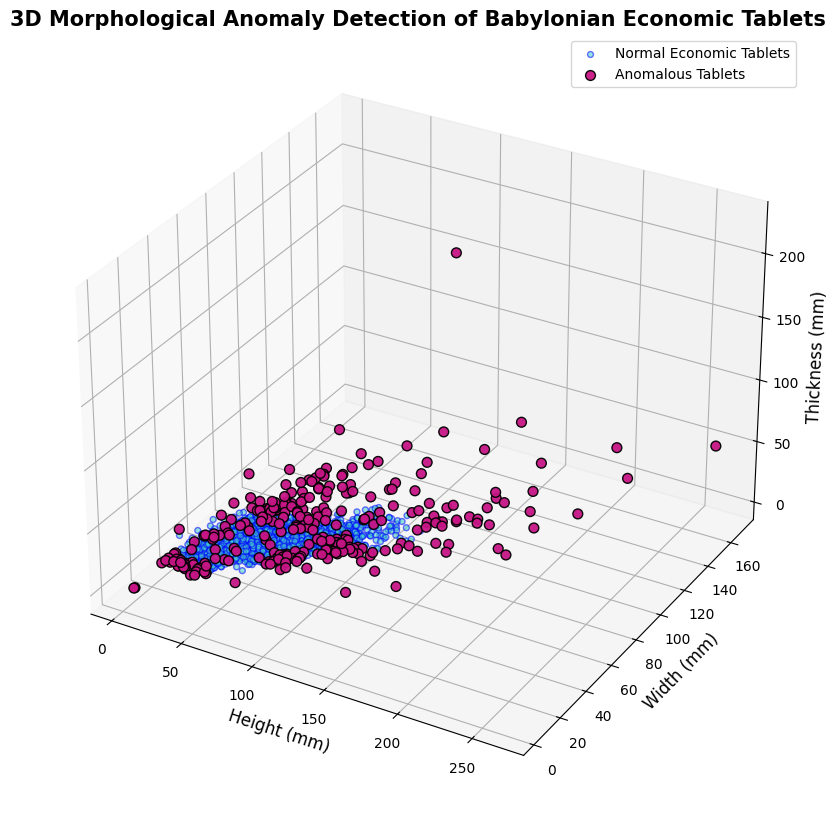

In [ ]:
plot_df = anomaly_df.select("id_text","height","width","thickness","distance","anomaly").toPandas()
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt

normal_df = plot_df[plot_df['anomaly'] == 0]
anomaly_only_df = plot_df[plot_df['anomaly'] == 1]
fig = plt.figure(figsize=(12, 10))
ax = fig.add_subplot(111, projection='3d')
# Normal tablets
ax.scatter(
    normal_df['height'],
    normal_df['width'],
    normal_df['thickness'],
    color='mediumturquoise',
    edgecolors='blue',
    alpha=0.55,
    s=18,
    label='Normal Economic Tablets'
)
# Anomalous tablets
ax.scatter(
    anomaly_only_df['height'],
    anomaly_only_df['width'],
    anomaly_only_df['thickness'],
    color='mediumvioletred',
    edgecolors='black',
    alpha=0.95,
    s=50,
    label='Anomalous Tablets')
ax.set_xlabel('Height (mm)', fontsize=12)
ax.set_ylabel('Width (mm)', fontsize=12)
ax.set_zlabel('Thickness (mm)', fontsize=12)
plt.title(
    '3D Morphological Anomaly Detection of Babylonian Economic Tablets',
    fontsize=15,
    fontweight='bold')
plt.legend()
plt.show()

# Interpreting the 3D Archaeological Visualization

This 3D plot helps us understand how Old Babylonian economic tablets vary in their physical form based on three measurements:
- height
- width
- thickness

The turquoise points points represent tablets that closely follow the most common dimensional patterns in the dataset. These likely correspond to routine administrative tablets whose sizes remained relatively standardized across everyday economic activities.

The pink points represent tablets identified as anomalies through distance-based machine learning. These tablets differ noticeably from the dominant patterns and stand out because of their unusual dimensions.

*What makes the visualization interesting is that these anomalous tablets are not scattered randomly.*

 Many appear:
- taller than typical tablets
- thicker than the majority of records
- unusually wide in proportion to their size

This raises the possibility that some tablets may have been created for more specialized purposes such as:
- important administrative records,
- institutional accounting,
- rare transactions,
- or unique archival functions.

We can also observe a dense central cluster where most tablets are concentrated. This suggests that Babylonian economic documentation may have followed relatively consistent physical conventions, possibly reflecting standardized administrative practices.

The isolated outliers become archaeologically important because they may point toward records that differed from routine economic activity in some meaningful way.

By combining archaeological data with unsupervised machine learning, the analysis allows us to move beyond simple cataloging and begin exploring hidden structural patterns within ancient economic records.

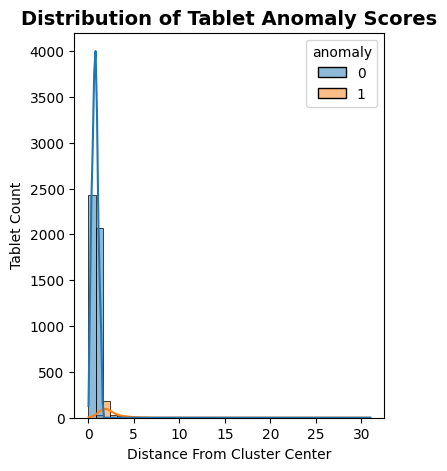

In [ ]:
import seaborn as sns
plt.figure(figsize=(4,5))
sns.histplot(data=plot_df,x='distance',hue='anomaly',bins=40,kde=True)
plt.title('Distribution of Tablet Anomaly Scores',fontsize=14,fontweight='bold')
plt.xlabel('Distance From Cluster Center')
plt.ylabel('Tablet Count')
plt.show()

# Distribution of Cluster Distances

This graph shows how far tablets lie from their assigned cluster centers after K-Means clustering was applied.

Most tablets are concentrated very close to their cluster centroids, forming the large peak on the left side of the distribution. This suggests that a majority of the economic tablets follow relatively consistent physical patterns and may reflect standardized administrative practices.

The blue distribution represents tablets classified as normal records, while the orange distribution represents tablets identified as anomalous through distance-based analysis.

The smaller orange distribution extending toward larger distance values indicates that only a limited number of tablets differ substantially from the dominant structural patterns observed in the dataset.

In [ ]:
anomaly_df.toPandas().to_csv('/content/drive/MyDrive/Ancient_Data /babylon_anomalies.csv',index=False)

# Transitioning to Supervised Learning

After identifying anomalous tablets through clustering distance analysis, we now transform the problem into a supervised classification task.

The objective is to determine whether machine learning models can predict anomalous economic tablets using only physical dimensions:
- height
- width
- thickness

The anomaly labels we generated during unsupervised learning will now be treated as target variables for classification models.

In [ ]:
from pyspark.sql.functions import col
supervised_df = anomaly_df.select(
    "scaled_features",
    col("anomaly").alias("label")
)
supervised_df.show(10, truncate=False)

+--------------------------------------------------------------+-----+
|scaled_features                                               |label|
+--------------------------------------------------------------+-----+
|[-1.0681837598900634,-1.0669803936148288,-1.378816928709013]  |0    |
|[1.4435708095289095,0.5226204908709507,1.0289511529368696]    |0    |
|[-0.858870879105149,-0.007246470624309028,-0.8972633123798365]|0    |
|[-1.3612217929889436,-1.7734696756085084,-1.8603705450381895] |1    |
|[0.2714186771333888,0.2576870101233209,-0.736745440270111]    |0    |
|[-0.7332831506342005,-0.7137357526179888,-0.736745440270111]  |0    |
|[-0.9425960314191149,-0.9786692333656187,-0.8972633123798365] |0    |
|[-0.6495579983202346,-0.8020469128671988,-0.736745440270111]  |0    |
|[-0.9844586075760977,-1.0669803936148288,-0.736745440270111]  |0    |
|[-0.8170083029481662,-0.9786692333656187,-0.736745440270111]  |0    |
+--------------------------------------------------------------+-----+
only s

In [ ]:
train_df, test_df = supervised_df.randomSplit([0.8, 0.2], seed=726)
print("Training Rows:", train_df.count())
print("Testing Rows:", test_df.count())

Training Rows: 3778
Testing Rows: 998


# Logistic Regression Classification

Logistic Regression is used as the first supervised classification model.

The algorithm estimates the probability that a tablet belongs to the anomalous class based on its physical dimensions:
- height
- width
- thickness

This model provides a statistically interpretable baseline for understanding whether anomalous tablets can be distinguished from standard economic records using physical measurements alone.

In [ ]:
from pyspark.ml.classification import LogisticRegression
lr = LogisticRegression(featuresCol="scaled_features",labelCol="label")
lr_model = lr.fit(train_df)
print("Logistic Regression model trained successfully!")

Logistic Regression model trained successfully!


The trained Logistic Regression model is now applied to unseen testing data.
For each tablet, the model predicts if it is anomalous, the probability of anomaly, and the confidence of the classification decision.

In [ ]:
lr_predictions = lr_model.transform(test_df)
lr_predictions.select("label","prediction","probability").show(25, truncate=False)

+-----+----------+------------------------------------------+
|label|prediction|probability                               |
+-----+----------+------------------------------------------+
|1    |0.0       |[0.9932309846316354,0.006769015368364606] |
|0    |0.0       |[0.9962248557320209,0.0037751442679790914]|
|0    |0.0       |[0.9937392954472077,0.006260704552792262] |
|0    |0.0       |[0.9717955587703668,0.02820444122963317]  |
|0    |0.0       |[0.994204002911275,0.0057959970887250245] |
|0    |0.0       |[0.9949919157855827,0.005008084214417341] |
|0    |0.0       |[0.9924812670087838,0.007518732991216193] |
|0    |0.0       |[0.9695104734968027,0.03048952650319725]  |
|0    |0.0       |[0.9374001930700989,0.06259980692990108]  |
|1    |0.0       |[0.9237462458273753,0.0762537541726247]   |
|0    |0.0       |[0.9927819265188661,0.007218073481133902] |
|0    |0.0       |[0.9924966965344194,0.007503303465580591] |
|0    |0.0       |[0.9444819240542315,0.05551807594576852]  |
|0    |0

# Evaluating the Classification Model

As anomaly detection datasets are highly imbalanced, accuracy alone is insufficient for evaluation.
To evaluate the Logistic Regression model, we use:
- accuracy
- ROC-AUC score
- and confusion matrix analysis

Anomalous tablets represent only a small portion of the dataset, evaluation metrics beyond simple accuracy are necessary to understand model performance properly.

In [ ]:
from pyspark.ml.evaluation import BinaryClassificationEvaluator
from pyspark.ml.evaluation import MulticlassClassificationEvaluator
acc_eval=MulticlassClassificationEvaluator(
    labelCol="label",
    predictionCol="prediction",
    metricName="accuracy")
accuracy=acc_eval.evaluate(lr_predictions)
roc_eval=BinaryClassificationEvaluator(
    labelCol="label",
    rawPredictionCol="rawPrediction",
    metricName="areaUnderROC")
roc_auc=roc_eval.evaluate(lr_predictions)
print(f"Accuracy: {accuracy:.4f}")
print(f"ROC-AUC Score: {roc_auc:.4f}")

Accuracy: 0.9489
ROC-AUC Score: 0.6496


# Model Evaluation Interpretation

The Logistic Regression model achieved high overall accuracy because most tablets belong to the normal administrative class.

However, the dataset is highly imbalanced, with anomalous tablets representing only a small percentage of observations. In such cases, ROC-AUC becomes a more meaningful evaluation metric than accuracy alone.

The ROC-AUC score suggests that tablet dimensions contain some detectable structural information related to anomalous economic records, although physical measurements alone are insufficient for strong classification performance.

This indicates that additional variables such as:
- tablet genre
- archaeological provenience
- textual classifications
- chronological information

may be necessary for more reliable predictive modeling.



# Confusion Matrix

The confusion matrix helps us examine how the model classifies:
- normal tablets  and
- anomalous tablets

This provides a more detailed understanding of prediction performance beyond overall accuracy scores.

In [ ]:
confusion=lr_predictions.groupBy("label","prediction").count()
confusion.show()

+-----+----------+-----+
|label|prediction|count|
+-----+----------+-----+
|    1|       0.0|   50|
|    0|       0.0|  933|
|    1|       1.0|   14|
|    0|       1.0|    1|
+-----+----------+-----+



## Interpretation
The confusion matrix shows that the Logistic Regression model correctly classified most standard tablets but struggled to identify many anomalous tablets.


| Actual Class | Predicted Class | Count | Interpretation |
|---|---|---|---|
| Normal (0) | Normal (0) | 933 | Correctly classified standard administrative tablets |
| Anomaly (1) | Anomaly (1) | 14 | Correctly detected anomalous tablets |
| Anomaly (1) | Normal (0) | 50 | Missed anomalies (false negatives) |
| Normal (0) | Anomaly (1) | 1 | Incorrect anomaly prediction (false positive) |

These results show that the Logistic Regression model strongly favors the majority class (normal tablets).

This behavior is expected in highly imbalanced anomaly detection problems, where anomalous observations are rare compared to standard administrative records.

The model successfully minimizes false positives, producing only one false positive prediction. However, it misses a good number of anomalous tablets, indicating that tablet dimensions alone may not fully capture the structural complexity of economic irregularities.

This suggests that physical tablet dimensions contain only partial information about economic irregularities and that more advanced nonlinear models may improve anomaly detection performance.

# Support Vector Machine Classification

Support Vector Machines (SVMs) attempt to identify optimal decision boundaries between normal and anomalous tablets based on their physical dimensions.

Unlike Logistic Regression, SVM models are often better at handling difficult class separations and can perform effectively in anomaly-oriented classification tasks.

By applying SVM classification, we test whether anomalous economic tablets occupy distinguishable geometric regions within the dimensional space.



In [ ]:
from pyspark.ml.classification import LinearSVC
svm=LinearSVC(
    featuresCol="scaled_features",
    labelCol="label",
    maxIter=20)
svm_model = svm.fit(train_df)

In [ ]:
svm_predictions = svm_model.transform(test_df)
svm_accuracy = acc_eval.evaluate(svm_predictions)
svm_roc_auc = roc_eval.evaluate(svm_predictions)
print(f"SVM Accuracy: {svm_accuracy:.4f}")
print(f"SVM ROC-AUC Score: {svm_roc_auc:.4f}")
svm_confusion_df = svm_predictions.groupBy("label","prediction").count()
svm_confusion_df.show()

SVM Accuracy: 0.9439
SVM ROC-AUC Score: 0.6188
+-----+----------+-----+
|label|prediction|count|
+-----+----------+-----+
|    1|       0.0|   56|
|    0|       0.0|  934|
|    1|       1.0|    8|
+-----+----------+-----+



# Comparing Logistic Regression and SVM

The Support Vector Machine produced results comparable to Logistic Regression but showed slightly weaker anomaly detection performance overall.

| Metric | Logistic Regression | SVM |
|---|---|---|
| Accuracy | 94.89% | 94.39% |
| ROC-AUC | 0.6496 | 0.6188 |

The SVM model classified most tablets as normal administrative records, resulting in:
- very few anomaly detections,
- zero false positives,
- and a larger number of missed anomalies.

This suggests that the physical tablet measurements form relatively simple geometric relationships that Logistic Regression was already able to capture effectively.

Overall, Logistic Regression performed slightly better for this archaeological anomaly detection task using tablet dimensions alone.

# *Conclusion*

In this notebook, we combined archaeological data processing with machine learning techniques to explore structural patterns within Old Babylonian economic tablets.

Using only tablet dimensions:
- height
- width
- thickness

we applied:
- clustering
- anomaly detection
- Logistic Regression
- and Support Vector Machines

to investigate whether unusual economic records could be identified computationally.

The analysis revealed that most tablets follow relatively consistent geometric patterns, suggesting a possible degree of administrative standardization within Babylonian economic documentation.

At the same time, a smaller group of anomalous tablets displayed unusual dimensions that may reflect:
- specialized administrative functions
- rare economic activities
- institutional records
- non-standard archival practices

Although the supervised models achieved high overall accuracy, anomaly classification remained challenging because of dataset imbalance and limited dimensional information.

The next stage of the project will explore more advanced machine learning approaches, to determine whether nonlinear models can better capture hidden archaeological and economic patterns within the dataset.